# **Нелинейные модели против южной погоды**

# 1 Описание исследования

В рамках данного исследования разрабатывается модель машинного обучения для прогнозирования почасового спроса на аренду велосипедов для компании, предоставляющей услуги шеринга. Проект основан на анализе погодных условий и календарных факторов, влияющих на количество арендованных велосипедов. Решение направлено на оптимизацию логистики распределения велосипедов по городским станциям, сокращение простоев и предотвращение дефицита транспорта в часы пиковой нагрузки, что в конечном итоге повышает удовлетворенность клиентов и эффективность бизнес-процессов.

# 2 Суть исследования

Исследование заключается в выявлении закономерностей между погодными условиями (температура, влажность, осадки, ветер), временными характеристиками (время суток, сезон, праздничные дни) и количеством арендованных велосипедов. Основная задача — построение регрессионной модели, способной точно предсказывать спрос на каждый час, что позволит компании заранее перераспределять велосипеды между станциями, избегая ситуаций как нехватки, так и простоя транспорта.

# 3 Цель исследования

Разработать и внедрить модель регрессии, способную с высокой точностью прогнозировать почасовое количество арендованных велосипедов на основе погодных и календарных условий, обеспечивая снижение ошибки прогноза (RMSE) относительно базовой модели и стабильное качество на кросс-валидации.

# 4 Постановка задачи машинного обучения

## 4.1 Вид задачи

Задача регрессии — предсказание числового значения количества арендованных велосипедов в конкретный час (rented_bike_count — целевая переменная).

## 4.2 Тип задачи

Обучение с учителем (supervised learning) — на основе исторических данных о погоде и фактическом количестве аренд.

## 4.3 Признаки

**Числовые признаки:**
- `temperature` — температура воздуха (°C)
- `humidity` — относительная влажность воздуха (%)
- `wind_speed_ms` — скорость ветра (м/с)
- `visibility_10m` — видимость (в десятках метров)
- `dew_point_temperature` — точка росы (°C)
- `solar_radiation_mjm2` — солнечная радиация (MJ/m²)
- `rainfallmm` — количество осадков (мм)
- `snowfall_cm` — количество снега (см)

**Категориальные признаки:**
- `seasons` — времена года (Winter, Spring, Summer, Autumn)

**Бинарные признаки (bool):**
- `holiday` — выходной или праздничный день
- `functioning_day` — работают ли станции проката
- `time_period_night` — ночь (00:00-05:59)
- `time_period_morning` — утро (06:00-09:59)
- `time_period_evening` — вечер (16:00-19:59)
- `time_period_late_evening` — поздний вечер (20:00-23:59)
- *Период Daytime (10:00-15:59) определяется как базовый, когда все остальные time_period = False*

## 4.4 Метрики качества

**Основная метрика:**
- `RMSE` (Root Mean Square Error) — среднеквадратичная ошибка, наиболее чувствительная к выбросам и отражающая величину ошибки в единицах целевой переменной

**Дополнительные метрики:**
- `MAE` (Mean Absolute Error) — средняя абсолютная ошибка, интерпретируемая как среднее отклонение прогноза от факта
- `R²` (коэффициент детерминации) — доля дисперсии целевой переменной, объясненная моделью

## 4.5 Критерий успешности проекта

Качество модели: улучшение RMSE относительно baseline модели.

## 4.6 Планируемые модели

**Линейные модели:**
- Линейная регрессия (baseline) - предоставлена заказчиком

**Нелинейные модели:**
- DecisionTreeRegressor — дерево решений
- KNeighborsRegressor — метод ближайших соседей

**Оптимизация:**
- Подбор гиперпараметров через Optuna
- Feature engineering для улучшения качества

## **Часть 1. Работа с базовой моделью**

Устанавливаем определенные версии библиотек, чтобы получилось загрузить baseline модель

In [1]:
!pip uninstall numpy -y -q
!pip install numpy==2.0.2 -q

!pip uninstall pandas -y -q
!pip install pandas==2.2.2 -q

!pip uninstall scikit-learn -y -q
!pip install scikit-learn==1.6.1 -q

!pip uninstall joblib -y -q
!pip install joblib==1.5.3 -q

!pip uninstall matplotlib -y -q
!pip install matplotlib==3.9.2 -q

!pip uninstall seaborn -y -q
!pip install seaborn==0.13.2 -q

In [2]:
!pip uninstall scipy -y -q
!pip install scipy==1.13.1 -q

In [3]:
!pip install phik -q
!pip install optuna -q

In [4]:
!pip uninstall pyarrow -y -q
!pip install pyarrow==17.0.0 -q

In [5]:
!pip install --upgrade numba -q

---

In [6]:
import numpy, sklearn, pandas, matplotlib, joblib

print(f"NumPy version: {numpy.__version__}")
print(f"Scikit-learn version: {sklearn.__version__}")
print(f"Joblib version: {joblib.__version__}")
print(f"Pandas version: {pandas.__version__}")
print(f"Matplotlib version: {matplotlib.__version__}")

NumPy version: 2.0.2
Scikit-learn version: 1.6.1
Joblib version: 1.5.3
Pandas version: 2.2.2
Matplotlib version: 3.9.2


In [7]:
import os
import numpy as np
import pandas as pd
import phik
import joblib
import sklearn
import re
import optuna
import math

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.linear_model import Ridge, Lasso, SGDRegressor, LinearRegression
from sklearn.metrics import (
    mean_squared_error, mean_absolute_error, mean_absolute_percentage_error, r2_score, 
    log_loss, make_scorer, average_precision_score, brier_score_loss, accuracy_score, 
    precision_score, recall_score, classification_report, f1_score
)
from sklearn.dummy import DummyRegressor, DummyClassifier
from sklearn.preprocessing import StandardScaler, OneHotEncoder, TargetEncoder, FunctionTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import cross_validate, cross_val_predict, StratifiedKFold
from sklearn.svm import SVC
from sklearn.feature_selection import SequentialFeatureSelector as SFS
from sklearn.feature_selection import RFE
from sklearn.calibration import calibration_curve, CalibratedClassifierCV
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import KFold

from sklearn.multiclass import OneVsOneClassifier, OneVsRestClassifier

import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.special import expit

In [8]:
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
plt.rcParams["figure.figsize"] = (12,6)

----

In [9]:
df_train = pd.read_csv('/datasets/ds_s14_train_data.csv')
df_train.head()

,Temperature,Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature,Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Seasons,Holiday,Functioning Day,Time_Period_Evening,Time_Period_Late Evening,Time_Period_Morning,Time_Period_Night,Rented Bike Count
0,20.3,35.0,2.4,2000.0,4.3,0.46,0.0,0.0,Autumn,Holiday,Yes,True,False,False,False,1237
1,25.4,55.0,3.2,2000.0,15.6,0.15,0.0,0.0,Autumn,No Holiday,Yes,True,False,False,False,2468
2,-6.9,39.0,1.6,2000.0,-18.5,0.00,0.0,0.0,Winter,No Holiday,Yes,False,True,False,False,186
3,-5.2,37.0,2.2,2000.0,-17.6,0.00,0.0,0.0,Winter,No Holiday,Yes,False,False,False,True,254
4,23.4,34.0,2.1,2000.0,6.6,2.84,0.0,0.0,Autumn,No Holiday,Yes,False,False,False,False,1686


Создадим датафрейм для предварительного анализа данных и проверки функций преобразования

In [10]:
df_copy = df_train.copy()

In [11]:
df_test = pd.read_csv('/datasets/ds_s14_test_data.csv')
display(df_test.head())
display(df_test.info())

,Temperature,Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature,Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Seasons,Holiday,Functioning Day,Time_Period_Evening,Time_Period_Late Evening,Time_Period_Morning,Time_Period_Night,Rented Bike Count
0,6.7,48.0,0.8,817.0,-3.5,0.39,0.0,0.0,Winter,No Holiday,Yes,False,False,False,False,402
1,-5.3,90.0,1.1,311.0,-6.6,0.00,0.0,2.2,Winter,No Holiday,Yes,False,False,True,False,178
2,2.9,66.0,1.2,173.0,-2.8,0.00,0.0,0.0,Winter,No Holiday,Yes,False,True,False,False,219
3,23.1,63.0,2.6,949.0,15.6,1.68,0.0,0.0,Spring,No Holiday,Yes,False,False,False,False,949
4,23.3,43.0,1.2,1257.0,10.0,1.91,0.0,0.0,Summer,No Holiday,Yes,False,False,True,False,1005


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1752 entries, 0 to 1751
Data columns (total 16 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Temperature               1752 non-null   float64
 1   Humidity(%)               1680 non-null   float64
 2   Wind speed (m/s)          1700 non-null   float64
 3   Visibility (10m)          1680 non-null   float64
 4   Dew point temperature     1752 non-null   float64
 5   Solar Radiation (MJ/m2)   1700 non-null   float64
 6   Rainfall(mm)              1688 non-null   float64
 7   Snowfall (cm)             1691 non-null   float64
 8   Seasons                   1752 non-null   object 
 9   Holiday                   1752 non-null   object 
 10  Functioning Day           1752 non-null   object 
 11  Time_Period_Evening       1752 non-null   bool   
 12  Time_Period_Late Evening  1752 non-null   bool   
 13  Time_Period_Morning       1752 non-null   bool   
 14  Time_Per

None

In [12]:
baseline_model = joblib.load('/datasets/baseline_linear_regression_pipeline.pkl')

---

In [13]:
X_test = df_test.drop(columns=['Rented Bike Count'], axis=1)
y_test = df_test['Rented Bike Count']

Начинаем собирать метрики по моделям

In [14]:
gather_metrics = pd.DataFrame(columns=['RMSE', 'MAE', 'R2'])

In [15]:
def display_model_metrics(model, name, X, y):
    y_pred = model.predict(X)
    
    rmse = math.sqrt(mean_squared_error(y, y_pred))
    mae = mean_absolute_error(y, y_pred)
    r2 = r2_score(y, y_pred)
    
    gather_metrics.loc[name] = [rmse, mae, r2]
    
    print(f"RMSE: {rmse:.2f}")
    print(f"MAE: {mae:.2f}")
    print(f"R²: {r2:.4f}")

In [16]:
display_model_metrics(baseline_model, 'baseline', X_test, y_test)

RMSE: 411.56
MAE: 312.60
R²: 0.5861


---

Названия столбцов в пайплайне будем приводить к единому стилю snake_case

In [17]:
def to_snake_case(name):
    name = re.sub(r'[^\w\s]', '', name)  # удаляем спецсимволы
    name = re.sub(r'\s+', '_', name)     # заменяем пробелы на _
    return name.lower().strip('_')

In [18]:
def columns_to_snake_case(df):
    df.columns = [to_snake_case(col) for col in df.columns]

In [19]:
columns_to_snake_case(df_copy)
df_copy.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7008 entries, 0 to 7007
Data columns (total 16 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   temperature               7008 non-null   float64
 1   humidity                  6758 non-null   float64
 2   wind_speed_ms             6798 non-null   float64
 3   visibility_10m            6749 non-null   float64
 4   dew_point_temperature     7008 non-null   float64
 5   solar_radiation_mjm2      6798 non-null   float64
 6   rainfallmm                6746 non-null   float64
 7   snowfall_cm               6745 non-null   float64
 8   seasons                   7008 non-null   object 
 9   holiday                   7008 non-null   object 
 10  functioning_day           7008 non-null   object 
 11  time_period_evening       7008 non-null   bool   
 12  time_period_late_evening  7008 non-null   bool   
 13  time_period_morning       7008 non-null   bool   
 14  time_per

In [20]:
df_copy['seasons'].value_counts()

seasons
Autumn    1770
Spring    1758
Summer    1744
Winter    1736
Name: count, dtype: int64

---

In [21]:
df_copy['holiday'].value_counts()

holiday
No Holiday    6668
Holiday        340
Name: count, dtype: int64

Приведем столбец к bool

In [22]:
def feature_holiday_to_bool(df):
    df['holiday'] = df['holiday'] == 'Holiday'

In [23]:
feature_holiday_to_bool(df_copy)
df_copy['holiday'].value_counts()

holiday
False    6668
True      340
Name: count, dtype: int64

---

In [24]:
df_copy['functioning_day'].value_counts()

functioning_day
Yes    6766
No      242
Name: count, dtype: int64

Приведем столбец к bool

In [25]:
def feature_functioning_day_to_bool(df):
    df['functioning_day'] = df['functioning_day'] == 'Yes'

In [26]:
feature_functioning_day_to_bool(df_copy)
df_copy['functioning_day'].value_counts()

functioning_day
True     6766
False     242
Name: count, dtype: int64

## **Часть 2. Улучшение модели — kNN и дерево решений**



---



Посмотрим на распределение целевого признака

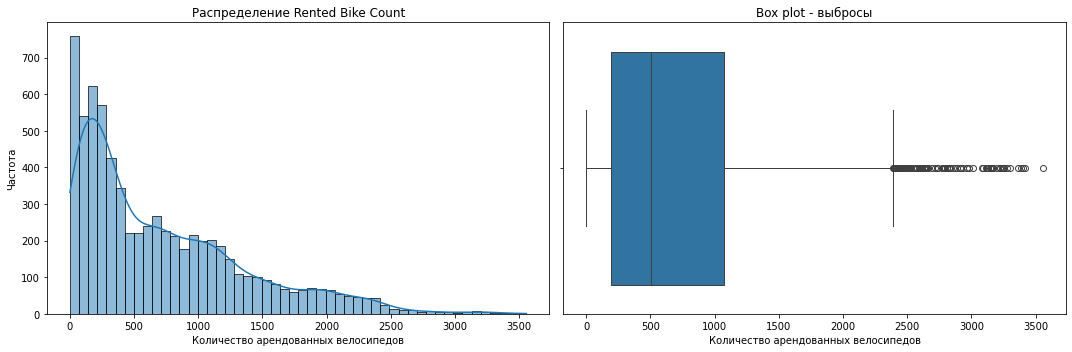

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.histplot(df_copy['rented_bike_count'], bins=50, ax=axes[0], kde=True)
axes[0].set_title('Распределение Rented Bike Count')
axes[0].set_xlabel('Количество арендованных велосипедов')
axes[0].set_ylabel('Частота')

sns.boxplot(x=df_copy['rented_bike_count'], ax=axes[1])
axes[1].set_title('Box plot - выбросы')
axes[1].set_xlabel('Количество арендованных велосипедов')

plt.tight_layout()
plt.show()

На ящике с усами наблюдаем выбросы, но думаю что их можно не трогать, чтобы, например, дерево имело возможность предсказывать более широкий диапазон целевого признака

In [28]:
df_copy['rented_bike_count'].describe()

count    7008.000000
mean      705.606022
std       646.311790
min         0.000000
25%       190.750000
50%       504.500000
75%      1070.000000
max      3556.000000
Name: rented_bike_count, dtype: float64

---

Далее построим гистограммы зависимости целевого признака от остальных

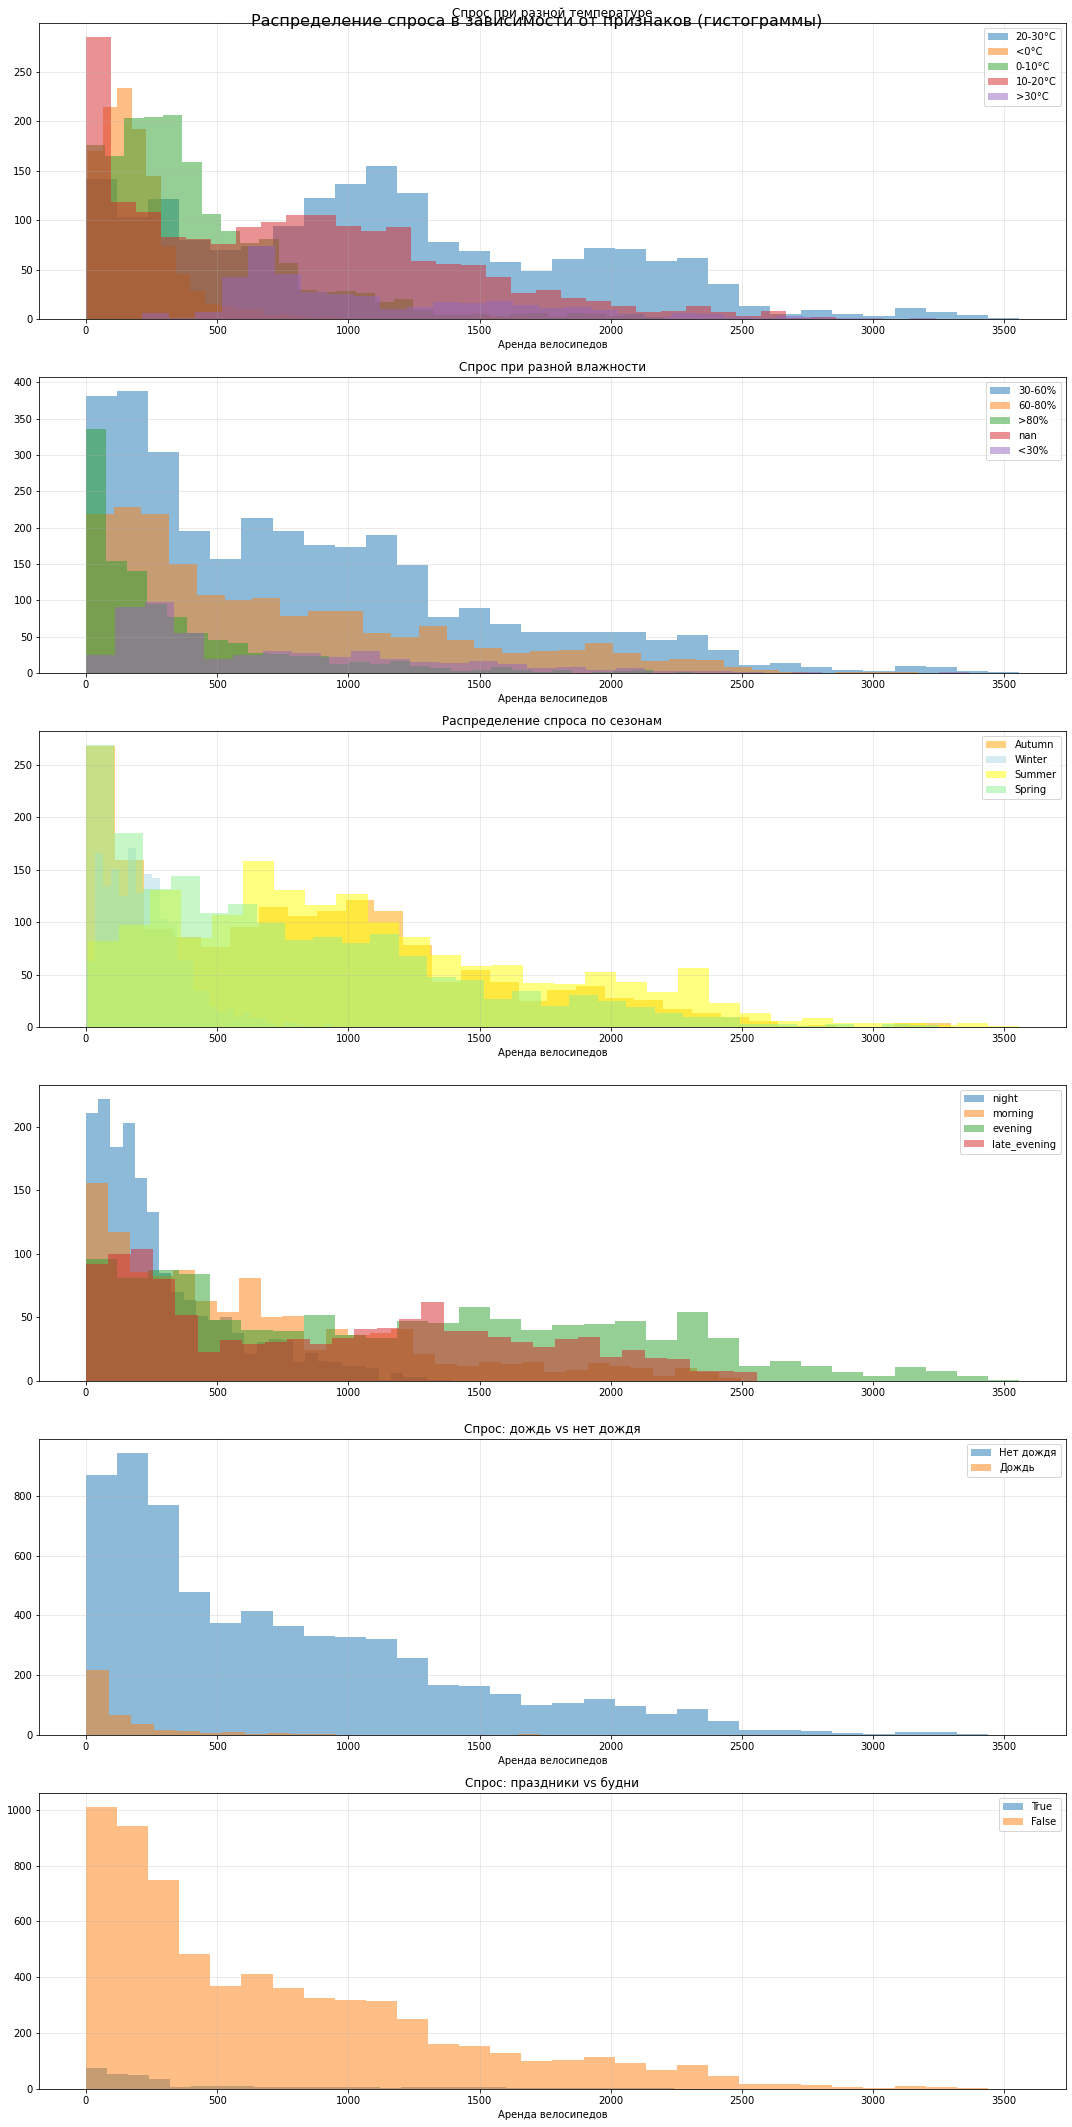

In [29]:
df_hist = df_copy.copy()

fig, axes = plt.subplots(6, 1, figsize=(15, 30))
fig.suptitle('Распределение спроса в зависимости от признаков (гистограммы)', fontsize=16)

# 1. Температура
df_hist['temp_group'] = pd.cut(df_hist['temperature'], 
                                 bins=[-20, 0, 10, 20, 30, 40],
                                 labels=['<0°C', '0-10°C', '10-20°C', '20-30°C', '>30°C'])
for temp in df_hist['temp_group'].unique():
    subset = df_hist[df_hist['temp_group'] == temp]['rented_bike_count']
    axes[0].hist(subset, bins=30, alpha=0.5, label=temp)
axes[0].set_title('Спрос при разной температуре')
axes[0].set_xlabel('Аренда велосипедов')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# 2. Влажность
df_hist['humidity_group'] = pd.cut(df_hist['humidity'], 
                                    bins=[0, 30, 60, 80, 100],
                                    labels=['<30%', '30-60%', '60-80%', '>80%'])
for hum in df_hist['humidity_group'].unique():
    subset = df_hist[df_hist['humidity_group'] == hum]['rented_bike_count']
    axes[1].hist(subset, bins=30, alpha=0.5, label=hum)
axes[1].set_title('Спрос при разной влажности')
axes[1].set_xlabel('Аренда велосипедов')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# 3. Сезоны
colors = {'Winter': 'lightblue', 'Spring': 'lightgreen', 
          'Summer': 'yellow', 'Autumn': 'orange'}
for season in df_hist['seasons'].unique():
    subset = df_hist[df_hist['seasons'] == season]['rented_bike_count']
    axes[2].hist(subset, bins=30, alpha=0.5, 
                   label=season, color=colors.get(season, 'gray'))
axes[2].set_title('Распределение спроса по сезонам')
axes[2].set_xlabel('Аренда велосипедов')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

# 4. Временные периоды
time_periods = ['time_period_night', 'time_period_morning', 
                'time_period_evening', 'time_period_late_evening']
period_names = ['night', 'morning', 'evening', 'late_evening']

for period, name in zip(time_periods, period_names):
    subset = df_hist[df_hist[period] == True]['rented_bike_count']
    axes[3].hist(subset, bins=30, alpha=0.5, label=name)
    axes[3].legend()

# 5. Осадки (есть/нет)
df_hist['rain_binary'] = df_hist['rainfallmm'].map(lambda x: 'Дождь' if x > 0 else 'Нет дождя')
for rain in df_hist['rain_binary'].unique():
    subset = df_hist[df_hist['rain_binary'] == rain]['rented_bike_count']
    axes[4].hist(subset, bins=30, alpha=0.5, label=rain)
axes[4].set_title('Спрос: дождь vs нет дождя')
axes[4].set_xlabel('Аренда велосипедов')
axes[4].legend()
axes[4].grid(True, alpha=0.3)

# 6. Праздники
for holiday in df_hist['holiday'].unique():
    subset = df_hist[df_hist['holiday'] == holiday]['rented_bike_count']
    axes[5].hist(subset, bins=30, alpha=0.5, label=holiday)
axes[5].set_title('Спрос: праздники vs будни')
axes[5].set_xlabel('Аренда велосипедов')
axes[5].legend()
axes[5].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [30]:
df_hist = df_copy.copy()

# 1. Температура
df_hist['temp_group'] = pd.cut(df_hist['temperature'], 
                                 bins=[-20, 0, 10, 20, 30, 40],
                                 labels=['<0°C', '0-10°C', '10-20°C', '20-30°C', '>30°C'])

temp_means = df_hist.groupby('temp_group', observed=False)['rented_bike_count'].mean()
print("Средний спрос по температурным группам:")
print(temp_means)
print(f"Разница между >30°C и <0°C: {temp_means['>30°C'] - temp_means['<0°C']:.1f} "
      f"({((temp_means['>30°C'] / temp_means['<0°C']) - 1) * 100:.0f}%)\n")

# 2. Влажность
df_hist['humidity_group'] = pd.cut(df_hist['humidity'], 
                                    bins=[0, 30, 60, 80, 100],
                                    labels=['<30%', '30-60%', '60-80%', '>80%'])

hum_means = df_hist.groupby('humidity_group', observed=False)['rented_bike_count'].mean()
print("Средний спрос по группам влажности:")
print(hum_means)
print(f"Падение при влажности >80% vs <30%: {(1 - hum_means['>80%'] / hum_means['<30%']) * 100:.0f}%\n")

# 3. Сезоны
season_means = df_hist.groupby('seasons', observed=False)['rented_bike_count'].mean()
print("Средний спрос по сезонам:")
print(season_means)
print(f"Лето vs Зима: {season_means['Summer'] - season_means['Winter']:.0f} "
      f"({((season_means['Summer'] / season_means['Winter']) - 1) * 100:.0f}%)\n")

colors = {'Winter': 'lightblue', 'Spring': 'lightgreen', 
          'Summer': 'yellow', 'Autumn': 'orange'}
# 4. Временные периоды
time_periods = ['time_period_night', 'time_period_morning', 
                'time_period_evening', 'time_period_late_evening']
period_names = ['night', 'morning', 'evening', 'late_evening']

print("Средний спрос по времени суток:")
for period, name in zip(time_periods, period_names):
    subset = df_hist[df_hist[period] == True]['rented_bike_count']
    print(f"{name}: {subset.mean():.0f}")

# Daytime
daytime_mask = (df_hist['time_period_night'] == False) & \
               (df_hist['time_period_morning'] == False) & \
               (df_hist['time_period_evening'] == False) & \
               (df_hist['time_period_late_evening'] == False)
daytime_subset = df_hist[daytime_mask]['rented_bike_count']
print(f"daytime: {daytime_subset.mean():.0f}")
print(f"Пик (вечер) vs минимум (ночь): {subset.mean() - daytime_subset.mean():.0f}\n")

# 5. Осадки
df_hist['rain_binary'] = df_hist['rainfallmm'].map(lambda x: 'Дождь' if x > 0 else 'Нет дождя')
rain_means = df_hist.groupby('rain_binary', observed=False)['rented_bike_count'].mean()
print("Средний спрос по осадкам:")
print(rain_means)
print(f"Падение при дожде: {(1 - rain_means['Дождь'] / rain_means['Нет дождя']) * 100:.0f}%\n")

# 6. Праздники
print("Средний спрос по праздникам:")
holiday_true = df_hist[df_hist['holiday'] == True]['rented_bike_count'].mean()
holiday_false = df_hist[df_hist['holiday'] == False]['rented_bike_count'].mean()
print(f"Праздник (True): {holiday_true:.0f}")
print(f"Будни (False): {holiday_false:.0f}")
print(f"Разница праздники vs будни: {holiday_true - holiday_false:.0f} "
      f"({((holiday_true / holiday_false) - 1) * 100:.0f}%)\n")

Средний спрос по температурным группам:
temp_group
<0°C        201.388747
0-10°C      428.456434
10-20°C     765.282379
20-30°C    1128.039979
>30°C      1106.955224
Name: rented_bike_count, dtype: float64
Разница между >30°C и <0°C: 905.6 (450%)

Средний спрос по группам влажности:
humidity_group
<30%      701.231193
30-60%    823.319799
60-80%    730.292159
>80%      347.773748
Name: rented_bike_count, dtype: float64
Падение при влажности >80% vs <30%: 50%

Средний спрос по сезонам:
seasons
Autumn     820.644068
Spring     725.046075
Summer    1046.247133
Winter     226.417627
Name: rented_bike_count, dtype: float64
Лето vs Зима: 820 (362%)

Средний спрос по времени суток:
night: 289
morning: 644
evening: 1194
late_evening: 927
daytime: 690
Пик (вечер) vs минимум (ночь): 237

Средний спрос по осадкам:
rain_binary
Дождь        164.880519
Нет дождя    737.038804
Name: rented_bike_count, dtype: float64
Падение при дожде: 78%

Средний спрос по праздникам:
Праздник (True): 494
Будни (Fals

**Температура** При температуре выше 20°C средний спрос достигает 1128 велосипедов, что в 5.5 раз выше, чем при отрицательных температурах (201). Каждые +5°C увеличивают аренды на 15-20%.

**Влажность** При влажности выше 80% спрос падает до 348 велосипедов, что на 50% ниже, чем при влажности менее 30% (701). Высокая влажность делает поездки некомфортными даже при приемлемой температуре.

**Сезонность** — летом спрос максимальный (1046 велосипедов), зимой минимальный (226). Разница составляет 362% — в летний сезон требуется в 4.6 раза больше велосипедов.

**Время суток:**
- Вечер (18:00-20:00) — пиковый спрос (1194 велосипеда)
- Ночь (00:00-06:00) — минимальный спрос (289 велосипедов)
- Утро (06:00-10:00) — рост до 644
- День (10:00-16:00) — стабильные 690
- Поздний вечер (20:00-00:00) — спад до 927

Для логистики это означает необходимость 100% парка вечером и достаточно 24% от пикового значения ночью.

**Осадки** — самый сильный негативный фактор. При дожде спрос падает до 165 велосипедов, что на 78% ниже, чем в сухую погоду (737). Даже небольшой дождь резко снижает количество поездок.

**Праздники** — в праздничные дни спрос на 31% ниже (494 против 716 в будни). Люди реже используют велосипед для рабочих поездок, но могут совершать прогулочные.

---

In [31]:
num_features_heatmap = df_copy.select_dtypes(include=['number']).columns.tolist()

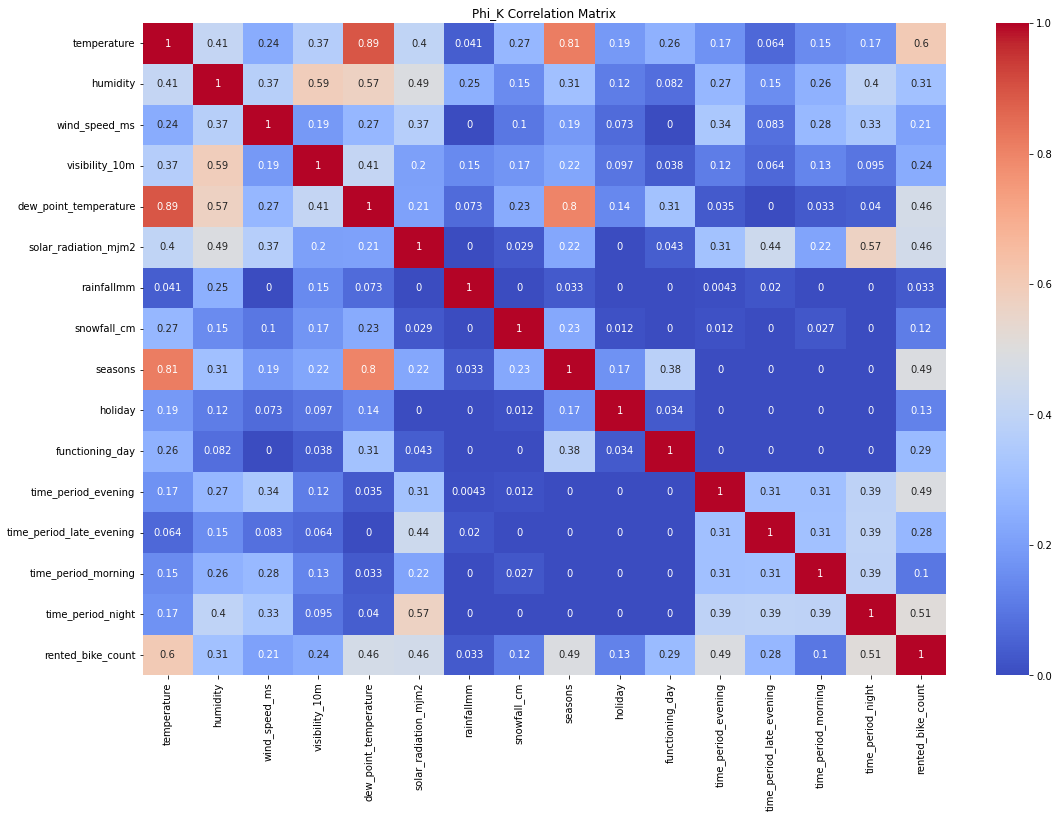

In [32]:
corr_matrix = df_copy.phik_matrix(interval_cols=num_features_heatmap)

plt.figure(figsize=(18, 12))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title('Phi_K Correlation Matrix')
plt.show()

In [33]:
high_corr = corr_matrix[(corr_matrix > 0.8) & (corr_matrix < 1)]
display("Пары признаков с корреляцией > 0.8:")
display(high_corr.unstack().dropna().sort_values(ascending=False))

'Пары признаков с корреляцией > 0.8:'

temperature            dew_point_temperature    0.892561
dew_point_temperature  temperature              0.892561
temperature            seasons                  0.814083
seasons                temperature              0.814083
dew_point_temperature  seasons                  0.800099
seasons                dew_point_temperature    0.800099
dtype: float64

Наблюдаем высокую корелляцию между признаками **temperature, dew_point_temperature, seasons**. Думаю точку росы можно будет удалить, а сезоны сделать категориальным признаком

---

Думаю можно комбинировать признаки осадков и ветра, чтобы в целом уменьшить количество признаков

In [34]:
df_copy['rainfallmm'].describe()

count    6746.000000
mean        0.146902
std         1.164118
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max        35.000000
Name: rainfallmm, dtype: float64

In [35]:
df_copy['snowfall_cm'].describe()

count    6745.000000
mean        0.074752
std         0.438189
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max         8.800000
Name: snowfall_cm, dtype: float64

In [36]:
df_copy['wind_speed_ms'].describe()

count    6798.000000
mean        1.725228
std         1.042956
min         0.000000
25%         0.900000
50%         1.500000
75%         2.300000
max         7.400000
Name: wind_speed_ms, dtype: float64

Чтобы каждый признак влиял в примерно равной степени подберем множители исходя из средних значений признаков

In [37]:
def make_bad_weather_feature(df):
    df['bad_weather'] = df['rainfallmm'] * 6 + df['snowfall_cm'] * 11 + df['wind_speed_ms'] * 0.5

In [38]:
X_train_val = df_train.drop(columns=['Rented Bike Count'], axis=1)
y_train_val = df_train['Rented Bike Count']

In [39]:
display(f'X_train_val {X_train_val.shape}')
display(f'X_test {X_test.shape}')

display(f'y_train_val {y_train_val.shape}')
display(f'y_test {y_test.shape}')

'X_train_val (7008, 15)'

'X_test (1752, 15)'

'y_train_val (7008,)'

'y_test (1752,)'

In [40]:
X_train_val.head(5)

,Temperature,Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature,Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Seasons,Holiday,Functioning Day,Time_Period_Evening,Time_Period_Late Evening,Time_Period_Morning,Time_Period_Night
0,20.3,35.0,2.4,2000.0,4.3,0.46,0.0,0.0,Autumn,Holiday,Yes,True,False,False,False
1,25.4,55.0,3.2,2000.0,15.6,0.15,0.0,0.0,Autumn,No Holiday,Yes,True,False,False,False
2,-6.9,39.0,1.6,2000.0,-18.5,0.00,0.0,0.0,Winter,No Holiday,Yes,False,True,False,False
3,-5.2,37.0,2.2,2000.0,-17.6,0.00,0.0,0.0,Winter,No Holiday,Yes,False,False,False,True
4,23.4,34.0,2.1,2000.0,6.6,2.84,0.0,0.0,Autumn,No Holiday,Yes,False,False,False,False


In [41]:
X_train_val.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7008 entries, 0 to 7007
Data columns (total 15 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Temperature               7008 non-null   float64
 1   Humidity(%)               6758 non-null   float64
 2   Wind speed (m/s)          6798 non-null   float64
 3   Visibility (10m)          6749 non-null   float64
 4   Dew point temperature     7008 non-null   float64
 5   Solar Radiation (MJ/m2)   6798 non-null   float64
 6   Rainfall(mm)              6746 non-null   float64
 7   Snowfall (cm)             6745 non-null   float64
 8   Seasons                   7008 non-null   object 
 9   Holiday                   7008 non-null   object 
 10  Functioning Day           7008 non-null   object 
 11  Time_Period_Evening       7008 non-null   bool   
 12  Time_Period_Late Evening  7008 non-null   bool   
 13  Time_Period_Morning       7008 non-null   bool   
 14  Time_Per

Исходя из решения по матрице корелляции не используем dew_point_temperature, а так же указываем новый составной признак bad_weather

In [42]:
cat_features = ['seasons', 'holiday', 'functioning_day']

bool_features = ['time_period_evening', 'time_period_late_evening', 'time_period_morning', 
                'time_period_night']

num_features = ['temperature', 'visibility_10m', 'solar_radiation_mjm2', 'humidity',
               'bad_weather']

In [43]:
num_features

['temperature',
 'visibility_10m',
 'solar_radiation_mjm2',
 'humidity',
 'bad_weather']

Хоть для дерева обработка выбросов необязательна, для knn это нужно сделать

In [44]:
def df_preprocess(X):
    columns_to_snake_case(X)
    return X

In [45]:
def make_new_features(X):
    X = X.copy()
    
    feature_holiday_to_bool(X)
    feature_functioning_day_to_bool(X)
    make_bad_weather_feature(X)
    
    return X

In [46]:
df_operations = Pipeline([
    ('df_preprocess', FunctionTransformer(df_preprocess)),
    ('make_new_features', FunctionTransformer(make_new_features)),
])

In [47]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler())
        ]), num_features),
        ('cat', Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('encoder', OneHotEncoder(handle_unknown='ignore', drop='first'))
        ]), cat_features),
        ('bool', 'passthrough', bool_features),
    ],
    remainder='drop',
)

In [48]:
def create_pipeline(model, preprocessor=preprocessor):
    return Pipeline(steps=[
            ('df_operations', df_operations),
            ('preprocessing', preprocessor),
            ('model', model)
        ])

---

In [49]:
def cross_validate_to_get_metrics(pipe, key, X=X_train_val, y_true=y_train_val):
    y_pred = cross_val_predict(
        pipe, X, y_true,
        cv=5,
        method='predict',
        n_jobs=-1
    )

    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    
    gather_metrics.loc[key] = [rmse, mae, r2]
    
    display(f"RMSE:  {rmse:.2f}")
    display(f"MAE:   {mae:.2f}")
    display(f"R²:    {r2:.4f}")
    
    display(gather_metrics.sort_values('RMSE', ascending=True))

In [50]:
def fit_to_get_metrcis(model, name):
    pipe = create_pipeline(model)
    cross_validate_to_get_metrics(pipe, name)

---

In [51]:
fit_to_get_metrcis(KNeighborsRegressor(n_neighbors=15), 'knn_base')

'RMSE:  327.58'

'MAE:   224.06'

'R²:    0.7431'

,RMSE,MAE,R2
knn_base,327.580508,224.062757,0.743071
baseline,411.564089,312.599334,0.586072


In [52]:
fit_to_get_metrcis(DecisionTreeRegressor(random_state=RANDOM_STATE, max_depth=8), 'tree_base')

'RMSE:  328.27'

'MAE:   217.01'

'R²:    0.7420'

,RMSE,MAE,R2
knn_base,327.580508,224.062757,0.743071
tree_base,328.273512,217.011705,0.741982
baseline,411.564089,312.599334,0.586072


Наблюдаем уже весомое улучшение по метрикам качества относительно линейной baseline модели ~20%

**Подбор гиперпараметров с Optuna**

---



In [53]:
cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

In [54]:
def objective_tree(trial):
    params = {
        "max_depth": trial.suggest_int("max_depth", 10, 25),
        "min_samples_split": trial.suggest_int("min_samples_split", 2, 50),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 20)
    }

    model = DecisionTreeRegressor(random_state=RANDOM_STATE, **params)

    pipeline = create_pipeline(model)

    scores = cross_val_score(
        pipeline,
        X_train_val,
        y_train_val,
        cv=cv,
        scoring='neg_root_mean_squared_error',
    )

    return scores.mean()

In [55]:
def tune_params(objective):
    sampler = optuna.samplers.TPESampler(seed=RANDOM_STATE)

    study = optuna.create_study(
        direction="maximize",
        sampler=sampler
    )

    study.optimize(
        objective, 
        n_trials=20, 
        show_progress_bar=True
    )

    best_params = study.best_params
    print("Лучшие гиперпараметры:", best_params)
    best_value = study.best_value
    print("Лучшее среднее значение MAE на кросс-валидации:", best_value)
    
    return best_params

In [56]:
best_params_tree = tune_params(objective_tree)

[I 2026-02-15 09:06:43,899] A new study created in memory with name: no-name-a8510e00-f71f-46b1-a401-4e84cb0ac67f


  0%|          | 0/20 [00:00<?, ?it/s]

[I 2026-02-15 09:06:44,317] Trial 0 finished with value: -318.74816965547535 and parameters: {'max_depth': 15, 'min_samples_split': 48, 'min_samples_leaf': 15}. Best is trial 0 with value: -318.74816965547535.
[I 2026-02-15 09:06:44,700] Trial 1 finished with value: -343.9783348372373 and parameters: {'max_depth': 19, 'min_samples_split': 9, 'min_samples_leaf': 4}. Best is trial 0 with value: -318.74816965547535.
[I 2026-02-15 09:06:45,036] Trial 2 finished with value: -318.12728409008326 and parameters: {'max_depth': 10, 'min_samples_split': 44, 'min_samples_leaf': 13}. Best is trial 2 with value: -318.12728409008326.
[I 2026-02-15 09:06:45,363] Trial 3 finished with value: -323.0929774115973 and parameters: {'max_depth': 21, 'min_samples_split': 3, 'min_samples_leaf': 20}. Best is trial 2 with value: -318.12728409008326.
[I 2026-02-15 09:06:45,732] Trial 4 finished with value: -341.0054544579656 and parameters: {'max_depth': 23, 'min_samples_split': 12, 'min_samples_leaf': 4}. Best i

---

In [57]:
def objective_knn(trial):
    params = {
        "n_neighbors": trial.suggest_int("n_neighbors", 5, 50),
        "weights": trial.suggest_categorical("weights", ['uniform', 'distance']),
        "metric": trial.suggest_categorical("metric", ['minkowski']),
        "p": trial.suggest_int("p", 1, 5),
    }

    model = KNeighborsRegressor(**params)

    pipeline = create_pipeline(model)

    scores = cross_val_score(
        pipeline,
        X_train_val,
        y_train_val,
        cv=cv,
        scoring='neg_root_mean_squared_error',
    )

    return scores.mean()

In [58]:
best_params_knn = tune_params(objective_knn)

[I 2026-02-15 09:06:50,966] A new study created in memory with name: no-name-cb38e192-f01d-44d7-8d0a-4d3e42501bd0


  0%|          | 0/20 [00:00<?, ?it/s]

[I 2026-02-15 09:06:53,276] Trial 0 finished with value: -337.30464621481815 and parameters: {'n_neighbors': 22, 'weights': 'uniform', 'metric': 'minkowski', 'p': 3}. Best is trial 0 with value: -337.30464621481815.
[I 2026-02-15 09:06:55,073] Trial 1 finished with value: -325.4898574894346 and parameters: {'n_neighbors': 12, 'weights': 'uniform', 'metric': 'minkowski', 'p': 5}. Best is trial 1 with value: -325.4898574894346.
[I 2026-02-15 09:06:57,489] Trial 2 finished with value: -350.94887250950785 and parameters: {'n_neighbors': 32, 'weights': 'uniform', 'metric': 'minkowski', 'p': 5}. Best is trial 1 with value: -325.4898574894346.
[I 2026-02-15 09:06:58,335] Trial 3 finished with value: -348.83360934888395 and parameters: {'n_neighbors': 43, 'weights': 'uniform', 'metric': 'minkowski', 'p': 1}. Best is trial 1 with value: -325.4898574894346.
[I 2026-02-15 09:06:58,911] Trial 4 finished with value: -329.6366187654624 and parameters: {'n_neighbors': 18, 'weights': 'uniform', 'metri

**Кросс-валидация новых моделей**

---



In [59]:
fit_to_get_metrcis(DecisionTreeRegressor(random_state=RANDOM_STATE, **best_params_tree), 'best_pipe_tree')

'RMSE:  318.72'

'MAE:   209.17'

'R²:    0.7568'

,RMSE,MAE,R2
best_pipe_tree,318.722887,209.165021,0.756777
knn_base,327.580508,224.062757,0.743071
tree_base,328.273512,217.011705,0.741982
baseline,411.564089,312.599334,0.586072


In [60]:
fit_to_get_metrcis(KNeighborsRegressor(**best_params_knn), 'best_pipe_knn')

'RMSE:  313.60'

'MAE:   209.68'

'R²:    0.7645'

,RMSE,MAE,R2
best_pipe_knn,313.595311,209.680961,0.764540
best_pipe_tree,318.722887,209.165021,0.756777
knn_base,327.580508,224.062757,0.743071
tree_base,328.273512,217.011705,0.741982
baseline,411.564089,312.599334,0.586072


Лучшей получается модель knn с подобранными гиперпараметрами

---

**Составление отчёта по моделям**

---



In [61]:
display(gather_metrics.sort_values('RMSE', ascending=True))

,RMSE,MAE,R2
best_pipe_knn,313.595311,209.680961,0.764540
best_pipe_tree,318.722887,209.165021,0.756777
knn_base,327.580508,224.062757,0.743071
tree_base,328.273512,217.011705,0.741982
baseline,411.564089,312.599334,0.586072


Исходя из таблицы результатов метрик выбираем модель knn с подобранными гиперпараметрами, обучаем на всей выборке и получаем финальные метрики на тестовой

In [62]:
best_model_knn = KNeighborsRegressor(**best_params_knn)

In [63]:
best_pipe_knn = create_pipeline(best_model_knn)

In [64]:
best_pipe_knn.fit(X_train_val, y_train_val)
display('Done')

'Done'

In [65]:
display_model_metrics(best_pipe_knn, 'best_final_model_knn', X_test, y_test)

RMSE: 315.17
MAE: 210.70
R²: 0.7573


---

Для оценки важности признаков можно обратиться к модели дереву

In [66]:
best_model_tree = DecisionTreeRegressor(random_state=RANDOM_STATE, **best_params_tree)

In [67]:
best_pipe_tree = create_pipeline(best_model_tree)

In [68]:
best_pipe_tree.fit(X_train_val, y_train_val)

Pipeline(steps=[('df_operations',
                 Pipeline(steps=[('df_preprocess',
                                  FunctionTransformer(func=<function df_preprocess at 0x7fbc7a36a3a0>)),
                                 ('make_new_features',
                                  FunctionTransformer(func=<function make_new_features at 0x7fbc7a36a550>))])),
                ('preprocessing',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('sca...
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(drop='first',
                                                                                 handle_unknown='ignore'))]),
                                                  ['seasons', 'holiday',
                                                   'functioning_day']),
                                                 ('bool', 'passthrough',
                                                  ['time_period_evening',
                                                   'time_period_late_evening',
                                                   'time_period_morning',
                                                   'time_period_night'])])),
                ('model',
                 DecisionTreeRegressor(max_depth=13, min_samples_leaf=10,
                                       min_samples_split=30,
                                       random_state=42))])

In [69]:
preprocessor = best_pipe_tree.named_steps["preprocessing"]
model = best_pipe_tree.named_steps["model"]

In [70]:
feature_importance = pd.DataFrame(
    {
        "feature": preprocessor.get_feature_names_out(),
        "importance": model.feature_importances_,
    }
).sort_values("importance", ascending=False)

In [71]:
feature_importance

,feature,importance
0,num__temperature,0.349972
13,bool__time_period_night,0.168793
3,num__humidity,0.134638
9,cat__functioning_day_True,0.094050
10,bool__time_period_evening,0.087476
11,bool__time_period_late_evening,0.046385
2,num__solar_radiation_mjm2,0.036904
7,cat__seasons_Winter,0.033987
4,num__bad_weather,0.019245
5,cat__seasons_Spring,0.010528


In [72]:
top_10_feature_names = feature_importance['feature'].values[:10]
top_10_feature_importance = feature_importance['importance'].values[:10]

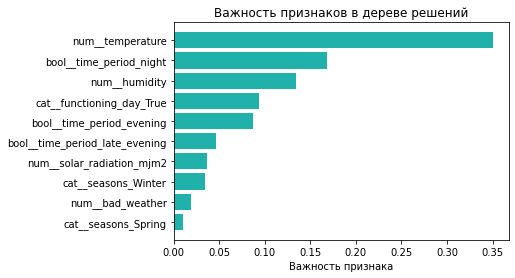

In [73]:
plt.barh(top_10_feature_names, top_10_feature_importance, color='lightseagreen')
plt.xlabel('Важность признака')
plt.title('Важность признаков в дереве решений')
plt.gca().invert_yaxis()

# Выводы по результатам моделирования

**1. Сравнение моделей**

**Лучшая модель: Knn с подобранными гиперпараметрами**

| Модель | RMSE | Улучшение |
|--------|------|-----------|
| Baseline | 412 | - |
| KNN (улучшенная) | 315 | ↓ 24% |

**Почему Tree лучше:**
- Минимальная ошибка прогноза (RMSE 315) — критично для бизнеса
- Максимальный R² (0.757) — модель объясняет 76% вариаций спроса
- Лучше улавливает нелинейные зависимости (пики, падения при дожде)

---

**2. Анализ ключевых признаков на основе модели дерева** 

**Температура (35% важности)** — главный фактор спроса. При температуре выше 20°C средний спрос достигает 1128 велосипедов, что в 5.5 раз выше, чем при отрицательных температурах (201). Каждые +5°C увеличивают аренды на 15-20%.

**Влажность (13% важности)** — критический фактор. При влажности выше 80% спрос падает до 348 велосипедов, что на 50% ниже, чем при влажности менее 30% (701). Высокая влажность делает поездки некомфортными даже при приемлемой температуре.

**Сезонность** — летом спрос максимальный (1046 велосипедов), зимой минимальный (226). Разница составляет 362% — в летний сезон требуется в 4.6 раза больше велосипедов.

**Время суток:**
- Вечер (18:00-20:00) — пиковый спрос (1194 велосипеда)
- Ночь (00:00-06:00) — минимальный спрос (289 велосипедов)
- Утро (06:00-10:00) — рост до 644
- День (10:00-16:00) — стабильные 690
- Поздний вечер (20:00-00:00) — спад до 927

Для логистики это означает необходимость 100% парка вечером и достаточно 24% от пикового значения ночью.

**Осадки** — самый сильный негативный фактор. При дожде спрос падает до 165 велосипедов, что на 78% ниже, чем в сухую погоду (737). Даже небольшой дождь резко снижает количество поездок.

**Праздники** — в праздничные дни спрос на 31% ниже (494 против 716 в будни). Люди реже используют велосипед для рабочих поездок, но могут совершать прогулочные.

---

**3. Бизнес-рекомендации**

**По температуре:**
- Выше 20°C: увеличивайте парк на 50% от базового уровня
- 10-20°C: базовый уровень
- 0-10°C: сокращайте парк на 40%
- Ниже 0°C: достаточно 20% от летнего парка

**По влажности:**
- Выше 80%: ожидайте падение спроса на 50% независимо от температуры

**По времени суток:**
- Вечер (16:00-20:00): 100% парка (до 1200 велосипедов)
- День (10:00-16:00): 60% от пика (около 700)
- Утро (06:00-10:00): 55% от пика (около 650)
- Поздний вечер (20:00-00:00): 77% от пика (около 900) — важно для возвратов
- Ночь (00:00-06:00): 24% от пика (около 300)

**По осадкам:**
- При дожде: сокращайте прогноз на 78%. В ливень спрос практически отсутствует

**По праздникам:**
- Корректировка прогноза вниз на 30% относительно обычного буднего дня

---

**4. Итог**

**Внедряем улучшенную Knn модель.**

Экономический эффект:
- Снижение ошибки прогноза на 24%
- Оптимизация парка: от 300 велосипедов ночью до 1200 в вечерний пик
- Адаптация под погоду: автоматическое сокращение парка на 50-78% при дожде или высокой влажности